In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
mass_sweep_results = xr.open_dataset("run_data/foswec_mass_on_top_sweep_results.nc")

In [3]:
wf = 1/3
amp = 0.25

case_results = mass_sweep_results.sel(
    wavefreq=wf,
    amplitude=amp,
    method="nearest",
)

print(case_results['avg_power'].values)
print(case_results.data_vars)

[-6.45387043 -6.45597012 -6.4582581  -6.46074595 -6.46341534 -6.46535861]
Data variables:
    avg_power                        (mass_on_top) float64 48B -6.454 ... -6.465
    objective                        (mass_on_top) float64 48B ...
    generated_power                  (mass_on_top) float64 48B ...
    success                          (mass_on_top) bool 6B ...
    flap1_total_mass                 (mass_on_top) float64 48B ...
    flap1_cg_height_above_hinge      (mass_on_top) float64 48B ...
    flap1_inertia_cg                 (mass_on_top) float64 48B ...
    flap2_total_mass                 (mass_on_top) float64 48B ...
    flap2_cg_height_above_hinge      (mass_on_top) float64 48B ...
    flap2_inertia_cg                 (mass_on_top) float64 48B ...
    opt_power                        (mass_on_top) float64 48B ...
    elec_power_W                     (mass_on_top) float64 48B ...
    mean_elec_power                  (mass_on_top) float64 48B ...
    opt_stiffness_flap1      

In [4]:
baseline_power = mass_sweep_results["elec_power_W"].sel(mass_on_top=0.0)

mass_sweep_results["power_improvement_pct"] = (
    100.0
    * (
        mass_sweep_results["elec_power_W"] - baseline_power
    )
    / np.abs(baseline_power)
)

valid_power = mass_sweep_results["generated_power"].where(
    mass_sweep_results["success"]
)

best_mass = valid_power.idxmax(dim="mass_on_top")
best_power = valid_power.max(dim="mass_on_top")

mass_sweep_results["best_mass_on_top"] = best_mass
mass_sweep_results["best_generated_power"] = best_power

print("\nBest mass by wave condition:")

for wavefreq in mass_sweep_results['wavefreq']:
    for amplitude in mass_sweep_results['amplitude']:
        bm = mass_sweep_results["best_mass_on_top"].sel(
            wavefreq=wavefreq,
            amplitude=amplitude,
        ).values

        bp = mass_sweep_results["best_generated_power"].sel(
            wavefreq=wavefreq,
            amplitude=amplitude,
        ).values

        print(
            f"wavefreq={wavefreq:.4f} Hz, "
            f"A={amplitude:.3f} m: "
            f"best_mass={float(bm):g} kg, "
            f"best_power={float(bp):.6g}"
        )


Best mass by wave condition:
wavefreq=0.1667 Hz, A=0.050 m: best_mass=0 kg, best_power=-0.32328
wavefreq=0.1667 Hz, A=0.100 m: best_mass=0 kg, best_power=-1.29312
wavefreq=0.1667 Hz, A=0.150 m: best_mass=1 kg, best_power=-1.61141
wavefreq=0.1667 Hz, A=0.200 m: best_mass=0 kg, best_power=-1.61133
wavefreq=0.1667 Hz, A=0.250 m: best_mass=0 kg, best_power=-1.6119
wavefreq=0.2000 Hz, A=0.050 m: best_mass=0 kg, best_power=-1.10078
wavefreq=0.2000 Hz, A=0.100 m: best_mass=0.5 kg, best_power=-2.32022
wavefreq=0.2000 Hz, A=0.150 m: best_mass=1.5 kg, best_power=-2.3212
wavefreq=0.2000 Hz, A=0.200 m: best_mass=0 kg, best_power=-2.32015
wavefreq=0.2000 Hz, A=0.250 m: best_mass=0 kg, best_power=-2.32059
wavefreq=0.2500 Hz, A=0.050 m: best_mass=2.5 kg, best_power=-2.50727
wavefreq=0.2500 Hz, A=0.100 m: best_mass=0 kg, best_power=-3.63007
wavefreq=0.2500 Hz, A=0.150 m: best_mass=0 kg, best_power=-3.6284
wavefreq=0.2500 Hz, A=0.200 m: best_mass=1.5 kg, best_power=-3.63056
wavefreq=0.2500 Hz, A=0.250

In [5]:
def plot_xr_res(
    ds,
    qnty,
    qnty2=None,
    qnty_label=None,
    qnty2_label=None,
    x_dim="mass_on_top",
    period_indices=None,
    amplitude_indices=None,
    xlabel=None,
    ylabel=None,
    mask_success=True,
    figsize_per_panel=(2.4, 3.2),
    show_quantity_legend=True,
    amplitude_legend_loc="upper left",
    quantity_legend_loc="lower left",
    amplitude_legend_bbox=None,
    quantity_legend_bbox=None,
    legend_plot_ind=-1,
):
    """
    Plot xarray sweep results versus x_dim.

    One subplot per selected wave period.
    One color per amplitude.
    qnty is plotted with solid lines.
    qnty2, if provided, is plotted with dashed lines.
    """

    wavefreq_all = ds["wavefreq"].values
    amplitude_all = ds["amplitude"].values

    if period_indices is None:
        period_indices = list(range(len(wavefreq_all)))

    if amplitude_indices is None:
        amplitude_indices = list(range(len(amplitude_all)))

    wavefreq_vals = wavefreq_all[period_indices]
    amplitude_vals = amplitude_all[amplitude_indices]

    ncols = len(wavefreq_vals)

    fig, axs = plt.subplots(
        1,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1]),
        sharey=True,
        constrained_layout=True,
    )

    axs = np.atleast_1d(axs)

    colors = plt.cm.viridis(
        np.linspace(0.0, 1.0, len(amplitude_vals))
    )
    colors = ["#9ecae1", "#4292c6", "#08519c"]

    if qnty_label is None:
        qnty_label = qnty

    if qnty2_label is None and qnty2 is not None:
        qnty2_label = qnty2

    for ax, wf in zip(axs, wavefreq_vals):
        period = 1.0 / wf

        for amp, color in zip(amplitude_vals, colors):
            y1 = ds[qnty].sel(
                wavefreq=wf,
                amplitude=amp,
            )

            if mask_success and "success" in ds:
                y1 = y1.where(
                    ds["success"].sel(
                        wavefreq=wf,
                        amplitude=amp,
                    )
                )

            ax.plot(
                ds[x_dim],
                y1,
                marker="o",
                linestyle="-",
                color=color,
            )

            if qnty2 is not None:
                y2 = ds[qnty2].sel(
                    wavefreq=wf,
                    amplitude=amp,
                )

                if mask_success and "success" in ds:
                    y2 = y2.where(
                        ds["success"].sel(
                            wavefreq=wf,
                            amplitude=amp,
                        )
                    )

                ax.plot(
                    ds[x_dim],
                    y2,
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    color=color,
                )

        ax.set_title(f"T = {period:.3f} s")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(xlabel if xlabel is not None else x_dim)

    if ylabel is None:
        if qnty2 is None:
            ylabel = qnty
        else:
            ylabel = f"{qnty_label} / {qnty2_label}"

    axs[0].set_ylabel(ylabel)

    # ------------------------------------------------------------------
    # Custom legends inside the last subplot
    # ------------------------------------------------------------------
    amp_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            marker="o",
            linestyle="-",
            label=f"A={amp:.3f} m",
        )
        for amp, color in zip(amplitude_vals, colors)
    ]

    amp_legend = axs[legend_plot_ind].legend(
        handles=amp_handles,
        fontsize=8,
        title_fontsize=9,
        loc=amplitude_legend_loc,
        bbox_to_anchor=amplitude_legend_bbox,
        framealpha=0.9,
    )

    axs[legend_plot_ind].add_artist(amp_legend)

    if show_quantity_legend:
        quantity_handles = [
            Line2D(
                [0],
                [0],
                color="k",
                linestyle="-",
                label=qnty_label,
            )
        ]

        if qnty2 is not None:
            quantity_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="k",
                    linestyle="--",
                    label=qnty2_label,
                )
            )

        axs[legend_plot_ind].legend(
            handles=quantity_handles,
            fontsize=8,
            title_fontsize=9,
            loc=quantity_legend_loc,
            framealpha=0.9,
            bbox_to_anchor=quantity_legend_bbox,
        )

    return fig, axs

In [6]:
mass_sweep_results.sel(
    wavefreq=1/3,
    amplitude=0.25,
    method="nearest",
)

<xarray.Dataset> Size: 1kB
Dimensions:                          (mass_on_top: 6)
Coordinates:
  * mass_on_top                      (mass_on_top) float64 48B 0.0 0.5 ... 2.5
    wavefreq                         float64 8B 0.3333
    amplitude                        float64 8B 0.25
Data variables: (12/30)
    avg_power                        (mass_on_top) float64 48B ...
    objective                        (mass_on_top) float64 48B ...
    generated_power                  (mass_on_top) float64 48B ...
    success                          (mass_on_top) bool 6B ...
    flap1_total_mass                 (mass_on_top) float64 48B ...
    flap1_cg_height_above_hinge      (mass_on_top) float64 48B ...
    ...                               ...
    flap2_peak_torque_utilization    (mass_on_top) float64 48B ...
    flap1_rms_torque_utilization     (mass_on_top) float64 48B ...
    flap2_rms_torque_utilization     (mass_on_top) float64 48B ...
    power_improvement_pct            (mass_on_top) float64 48B 0.0 ... 0.178
    best_mass_on_top                 float64 8B 0.0
    best_generated_power             float64 8B -6.454
Attributes:
    description:  Full-system FOSWEC added-top-mass sweep
    controller:   unstructured
    f1_factor:    1.0

In [7]:
# does flap 1 really have higher optimal stiffness and higher rotation utilization?
print(mass_sweep_results["flap1_peak_rotation_utilization"].sel(wavefreq=1/1,amplitude=0.05).values)
print(mass_sweep_results["flap2_peak_rotation_utilization"].sel(wavefreq=1/1,amplitude=0.05).values)

print(mass_sweep_results["opt_stiffness_flap1"].sel(wavefreq=1/1,amplitude=0.05).values)
print(mass_sweep_results["opt_stiffness_flap2"].sel(wavefreq=1/1,amplitude=0.05).values)

[0.13513151 0.13698838 0.13880351 0.14056578 0.14227515 0.14393184]
[0.04543063 0.04553787 0.04560914 0.04564554 0.04564818 0.04561815]
[536.92079928 524.07189442 512.26613483 501.41483061 491.43215807
 482.2478062 ]
[6.34201530e-14 0.00000000e+00 1.76421062e-14 9.17712025e-16
 0.00000000e+00 0.00000000e+00]


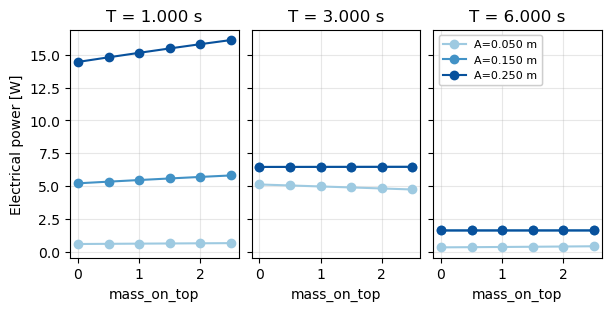

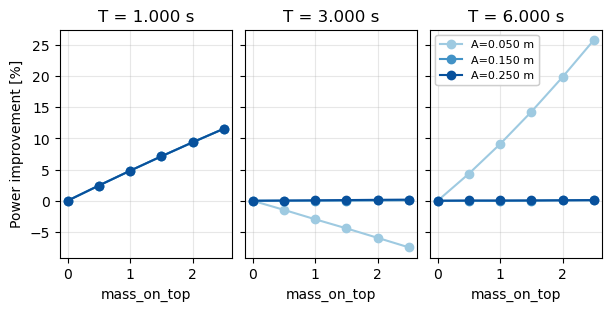

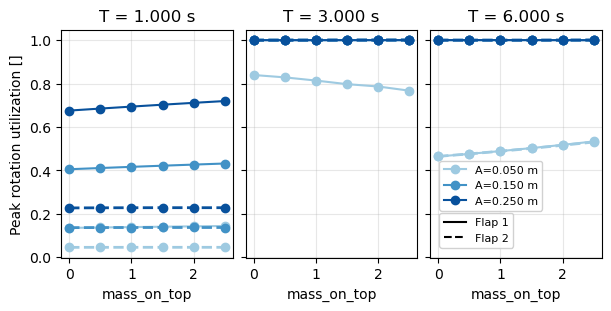

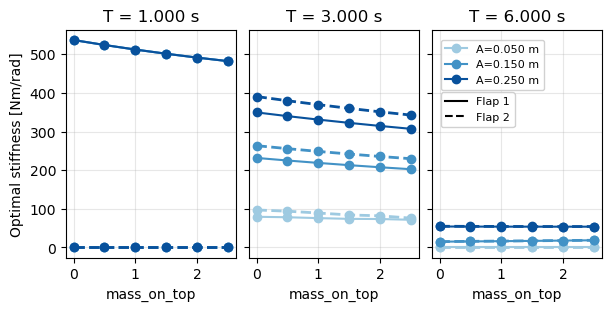

In [ ]:
fig, axs = plot_xr_res(
    mass_sweep_results,
    "elec_power_W",
    period_indices=[5, 3, 0],
    amplitude_indices=[0, 2, 4],
    ylabel="Electrical power [W]",
    figsize_per_panel=(2, 3),
    show_quantity_legend=False,
)

#fig.savefig("mass_power.pdf", format="pdf",  bbox_inches="tight",)

fig, axs = plot_xr_res(
    mass_sweep_results,
    "power_improvement_pct",
    period_indices=[5, 3, 0],
    amplitude_indices=[0, 2, 4],
    ylabel="Power improvement [%]",
    figsize_per_panel=(2, 3),
    show_quantity_legend=False,
)

#fig.savefig("mass_power_pct.pdf",format="pdf",bbox_inches="tight",)

fig, axs = plot_xr_res(
    mass_sweep_results,
    qnty="flap1_peak_rotation_utilization",
    qnty2="flap2_peak_rotation_utilization",
    qnty_label="Flap 1",
    qnty2_label="Flap 2",
    period_indices=[5, 3, 0],
    amplitude_indices=[0, 2, 4],
    ylabel="Peak rotation utilization []",
    amplitude_legend_bbox=(0.02, 0.45),
    quantity_legend_bbox=(0.02, 0.02),
    figsize_per_panel=(2, 3),
)

#fig.savefig("mass_rot_util.pdf",format="pdf",bbox_inches="tight",)

fig, axs = plot_xr_res(
    mass_sweep_results,
    qnty="opt_stiffness_flap1",
    qnty2="opt_stiffness_flap2",
    qnty_label="Flap 1",
    qnty2_label="Flap 2",
    period_indices=[5, 3, 0],
    amplitude_indices=[0, 2, 4],
    ylabel="Optimal stiffness [Nm/rad]",
    amplitude_legend_bbox=(0.02, 0.98),
    quantity_legend_bbox=(0.02, 0.55),
    figsize_per_panel=(2, 3),
)

#fig.savefig("mass_opt_stiffness.pdf",format="pdf", bbox_inches="tight",)

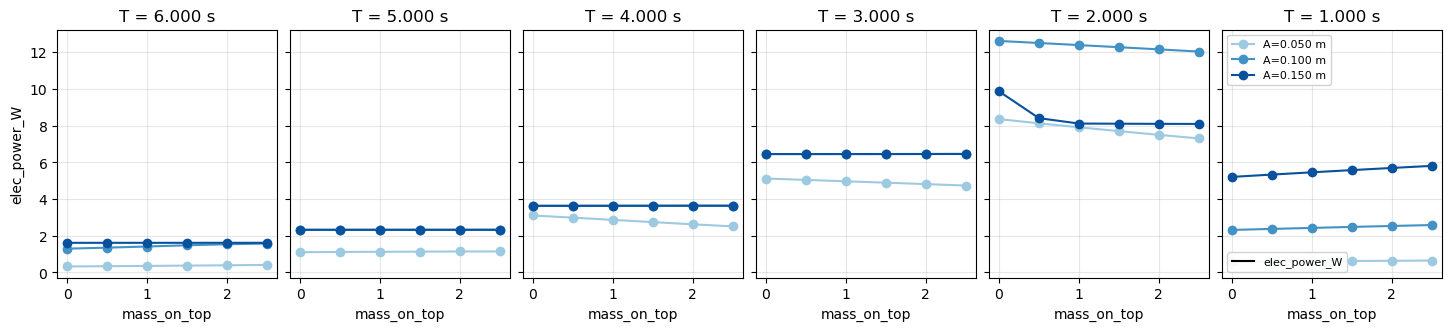

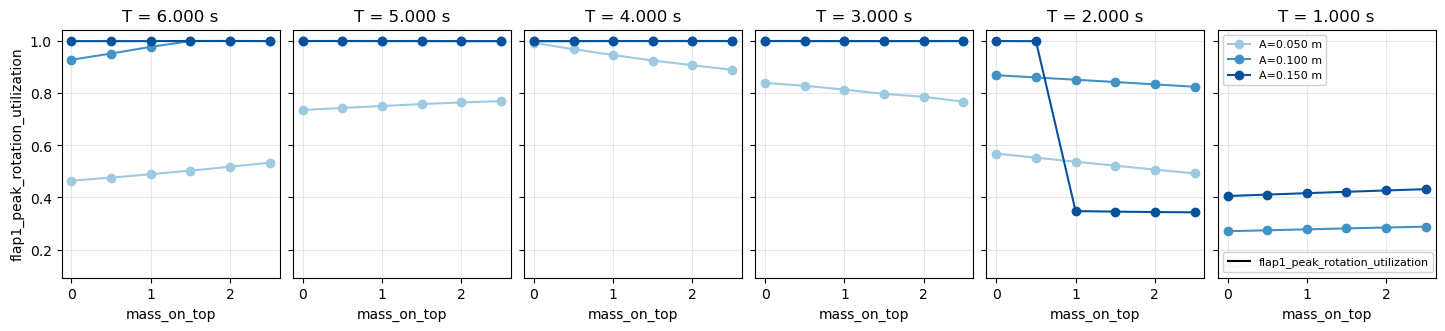

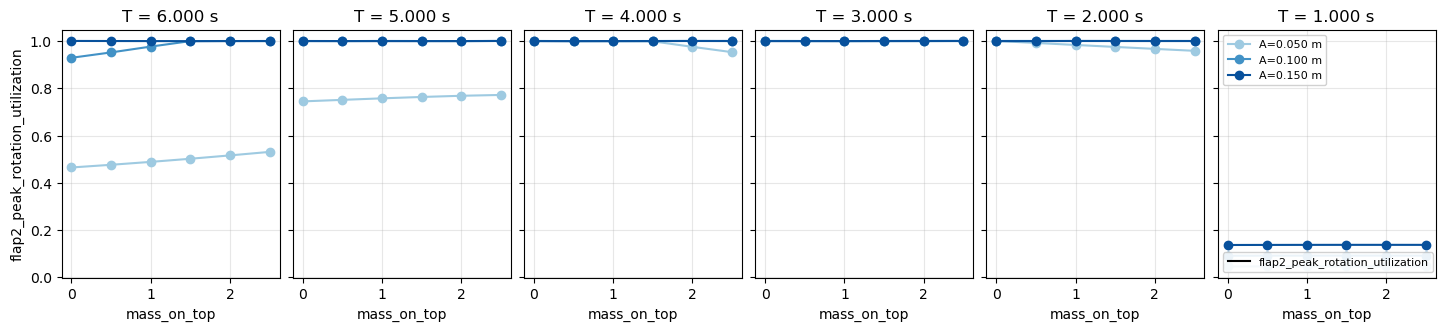

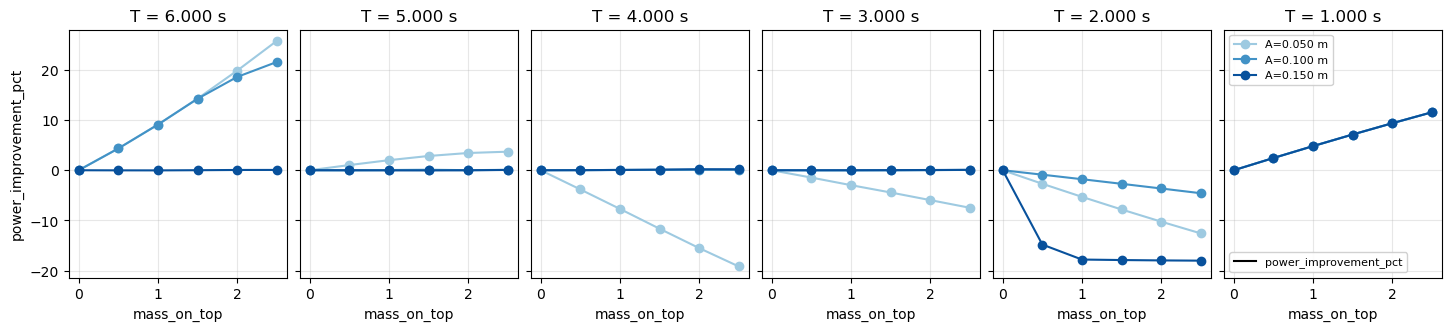

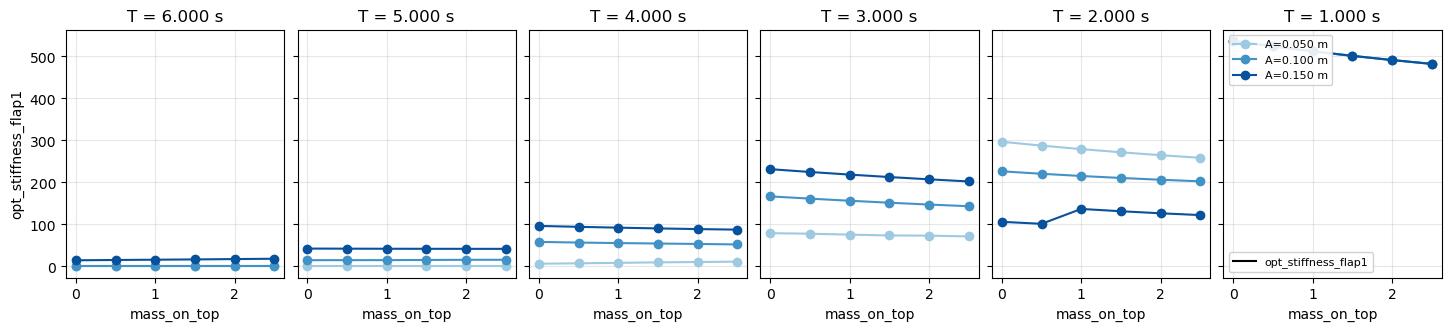

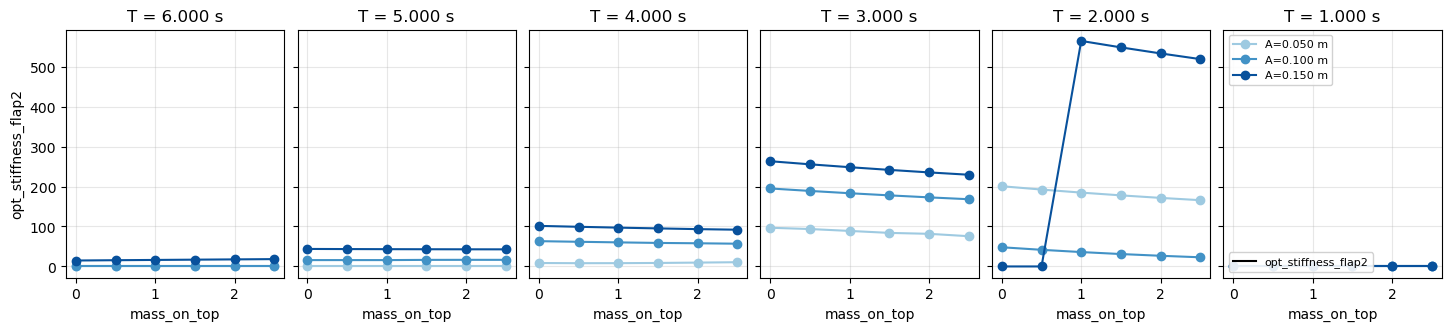

In [9]:
plot_xr_res(mass_sweep_results, "elec_power_W")
plot_xr_res(mass_sweep_results, "flap1_peak_rotation_utilization")
plot_xr_res(mass_sweep_results, "flap2_peak_rotation_utilization")
plot_xr_res(mass_sweep_results, "power_improvement_pct")
plot_xr_res(mass_sweep_results, "opt_stiffness_flap1")
plot_xr_res(mass_sweep_results, "opt_stiffness_flap2")
plt.show()

(<Figure size 1440x320 with 6 Axes>,
 array([<Axes: title={'center': 'T = 6.000 s'}, xlabel='mass_on_top', ylabel='flap2_peak_torque_utilization'>,
        <Axes: title={'center': 'T = 5.000 s'}, xlabel='mass_on_top'>,
        <Axes: title={'center': 'T = 4.000 s'}, xlabel='mass_on_top'>,
        <Axes: title={'center': 'T = 3.000 s'}, xlabel='mass_on_top'>,
        <Axes: title={'center': 'T = 2.000 s'}, xlabel='mass_on_top'>,
        <Axes: title={'center': 'T = 1.000 s'}, xlabel='mass_on_top'>],
       dtype=object))

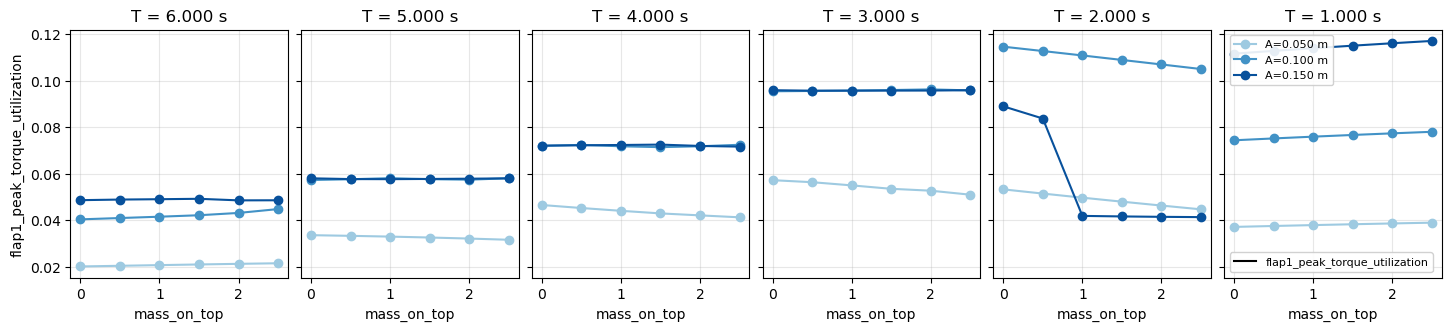

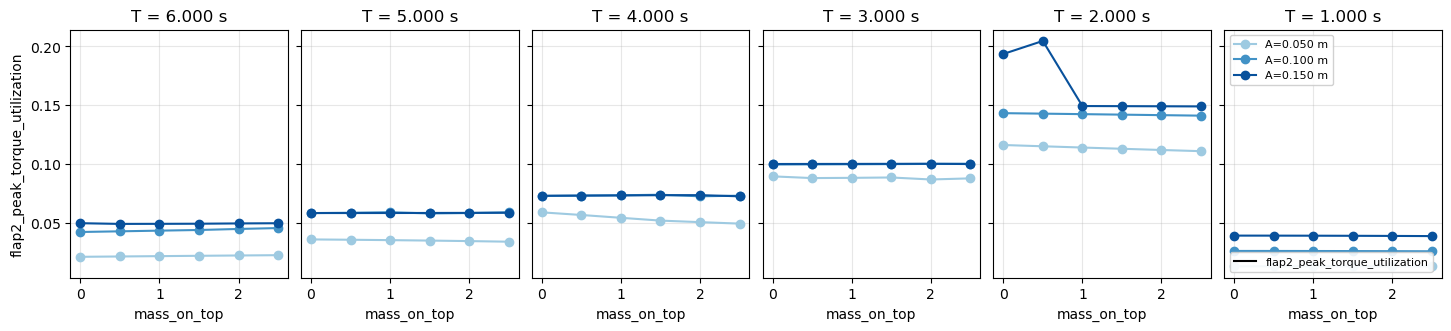

In [10]:
plot_xr_res(mass_sweep_results, "flap1_peak_torque_utilization")
plot_xr_res(mass_sweep_results, "flap2_peak_torque_utilization")

In [11]:
mass_sweep_results.close()